In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"
# os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" # Enable in M1 Mac CPUs

from matplotlib import rcParams
import matplotlib.pyplot as plt


# Some preambles for prettification
rcParams.update({'figure.figsize': (8, 6), 'axes.spines.top': False,
                 'axes.spines.right': False, 'axes.labelsize': 12,
                 'axes.titlesize': 12, 'axes.titleweight': 'bold',
                 'lines.linewidth': 1.5})

Reference: Chollet, F., & Watson, M. (2026). Deep learning with Python Third Edition. Manning.

Prepared by: Leodegario Lorenzo II

# Natural Language Processing using RNNs

In [2]:
import keras
from keras import layers

## 1 Data Preparation

### Downloading the Dataset

In [3]:
import os, pathlib, shutil, random

In [ ]:
# zip_path = keras.utils.get_file(
#     origin="https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
#     extract=True,
# )

# imdb_extract_dir = pathlib.Path(zip_path) / "aclImdb"

In [ ]:
# shutil.copytree(imdb_extract_dir, 'data/aclImdb');

In [4]:
data_dir = pathlib.Path('data/aclImdb')

### Sample Data

In [10]:
with open(data_dir / "train" / "pos" / "4077_10.txt") as f:
    print(f.read())

I first saw this back in the early 90s on UK TV, i did like it then but i missed the chance to tape it, many years passed but the film always stuck with me and i lost hope of seeing it TV again, the main thing that stuck with me was the end, the hole castle part really touched me, its easy to watch, has a great story, great music, the list goes on and on, its OK me saying how good it is but everyone will take there own best bits away with them once they have seen it, yes the animation is top notch and beautiful to watch, it does show its age in a very few parts but that has now become part of it beauty, i am so glad it has came out on DVD as it is one of my top 10 films of all time. Buy it or rent it just see it, best viewing is at night alone with drink and food in reach so you don't have to stop the film.<br /><br />Enjoy


In [18]:
from glob import glob

import numpy as np

In [20]:
np.random.seed(1337)
with open(np.random.choice(glob(f"{str(data_dir)}/train/neg/*.txt"))) as f:
    print(f.read())

This film is a Pia Zadora special! When viewing it, I was reminded of the classic cartoon showing a Hollywood starlet; in urgent need of another role but afraid of becoming typecast for 'B' movie or soft porn roles; who says at her casting session "Well of course I do not normally do roles requiring nudity, but if it is artistically necessary for the film...............". This recollection brought up a very naughty image of a similar cartoon showing Pia at such a session saying "Well of course I do not normally take any roles requiring actual acting, but if it will really give me sufficient exposure to enhance my status as a sex symbol..................". This is probably grossly unfair, the rather sordid tale is the fault of Harold Robbins book; considering the nature of the story Pia's exposures certainly do not receive undue attention, and perhaps Pia (who once won an acting award in Butterfly) is deliberately satirising her part rather than attempting to act in an almost unplayable

### Data Segregation

In [5]:
train_dir = pathlib.Path("imdb_train")
test_dir = pathlib.Path("imdb_test")
val_dir = pathlib.Path("imdb_val")

Copy files to test directory

In [22]:
# shutil.copytree(data_dir / "test", test_dir);

PosixPath('imdb_test')

Create a train-validation test data by randomly selecting data in our training set

In [23]:
# val_percentage = 0.2

# for category in ("neg", "pos"):
#     src_dir = data_dir / "train" / category
#     src_files = os.listdir(src_dir)
#     random.Random(1337).shuffle(src_files)
#     num_val_samples = int(len(src_files) * val_percentage)

#     os.makedirs(val_dir / category)
#     for file in src_files[:num_val_samples]:
#         shutil.copy(src_dir / file, val_dir / category / file)
#     os.makedirs(train_dir / category)
#     for file in src_files[num_val_samples:]:
#         shutil.copy(src_dir / file, train_dir / category / file)

### Creation of the Dataset

In [6]:
from keras.utils import text_dataset_from_directory

In [7]:
batch_size = 8

train_ds = text_dataset_from_directory(train_dir, batch_size=batch_size)
val_ds = text_dataset_from_directory(val_dir, batch_size=batch_size)
test_ds = text_dataset_from_directory(test_dir, batch_size=batch_size)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


#### Dataset Sampling (for manageable runtime)

In [8]:
train_ds = train_ds.take(200)
val_ds = val_ds.take(50)
test_ds = test_ds.take(250)

In [9]:
train_ds_no_labels = train_ds.map(lambda x, y: x)

## 2 Set-based Machine Learning Model

In [15]:
from keras import layers

### Bag-of-Words Model

#### Text Vectorization

In [27]:
max_tokens = 20_000

text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="multi_hot",
)

In [28]:
text_vectorization.adapt(train_ds_no_labels)

In [29]:
bag_of_words_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bag_of_words_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bag_of_words_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [30]:
x, y = next(bag_of_words_train_ds.as_numpy_iterator())
x.shape

(32, 20000)

In [31]:
y.shape

(32,)

#### Model Building

In [38]:
max_tokens = 20_000
name = "bag_of_words_classifier"

inputs = keras.Input(shape=(max_tokens,))
outputs = layers.Dense(1, activation="sigmoid")(inputs)
model = keras.Model(inputs, outputs, name=name)

In [39]:
model.summary()

Model: "bag_of_words_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        20,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,001 (78.13 KB)

 Trainable params: 20,001 (78.13 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [42]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)
model_checkpoint = keras.callbacks.ModelCheckpoint(
    "models/bow_model.keras", save_best_only=True
)

In [43]:
history = model.fit(
    bag_of_words_train_ds,
    validation_data=bag_of_words_val_ds,
    epochs=10,
    callbacks=[early_stopping, model_checkpoint],
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8414 - loss: 0.4585 - val_accuracy: 0.8778 - val_loss: 0.3586
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9065 - loss: 0.2937 - val_accuracy: 0.8862 - val_loss: 0.3049
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9284 - loss: 0.2360 - val_accuracy: 0.8940 - val_loss: 0.2830
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9416 - loss: 0.2006 - val_accuracy: 0.8966 - val_loss: 0.2721
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9517 - loss: 0.1751 - val_accuracy: 0.8956 - val_loss: 0.2663
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9595 - loss: 0.1552 - val_accuracy: 0.8968 - val_loss: 0.2636
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9657 - loss: 0.1388 - val_accuracy: 0.8954 - val_loss: 0.2627
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9708 - loss: 0.1254 - 

In [44]:
from utils import plot_history

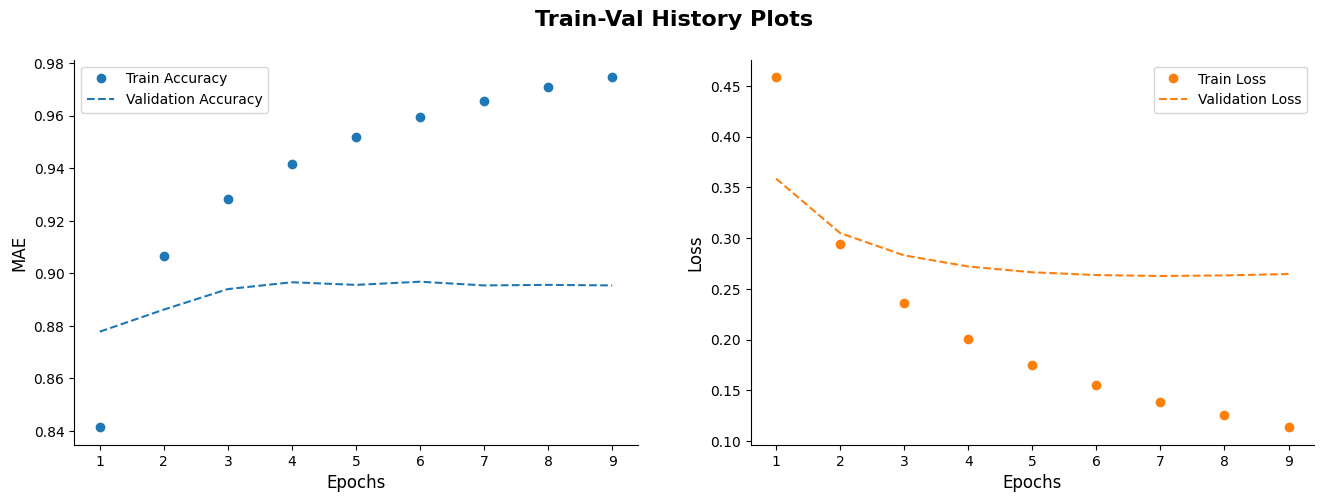

In [46]:
plot_history(history);

In [48]:
bow_model = keras.models.load_model("models/bow_model.keras")
bow_acc = bow_model.evaluate(bag_of_words_test_ds)[1]
bow_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8865 - loss: 0.2823


0.8865200281143188

### Bi-Gram Model

#### Text Vectorization

In [49]:
max_tokens = 30_000

text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="multi_hot",
    ngrams=2,
)

In [50]:
text_vectorization.adapt(train_ds_no_labels)

In [51]:
bigram_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bigram_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bigram_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [52]:
x, y = next(bigram_train_ds.as_numpy_iterator())
x.shape

(32, 30000)

In [53]:
text_vectorization.get_vocabulary()[100:108]

[np.str_('first'),
 np.str_('most'),
 np.str_('him'),
 np.str_('it was'),
 np.str_('dont'),
 np.str_('one of'),
 np.str_('then'),
 np.str_('for the')]

#### Model Building

In [54]:
name = "bigram_classifier"

inputs = keras.Input(shape=(max_tokens,))
outputs = layers.Dense(1, activation="sigmoid")(inputs)
model = keras.Model(inputs, outputs, name=name)

In [55]:
model.summary()

Model: "bigram_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 30000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │        30,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,001 (117.19 KB)

 Trainable params: 30,001 (117.19 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [57]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)
model_checkpoint = keras.callbacks.ModelCheckpoint(
    "models/bigram_model.keras", save_best_only=True
)

In [58]:
history = model.fit(
    bigram_train_ds,
    validation_data=bigram_val_ds,
    epochs=10,
    callbacks=[early_stopping, model_checkpoint],
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8641 - loss: 0.3995 - val_accuracy: 0.8958 - val_loss: 0.3021
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9352 - loss: 0.2240 - val_accuracy: 0.9016 - val_loss: 0.2637
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9604 - loss: 0.1644 - val_accuracy: 0.9012 - val_loss: 0.2511
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9743 - loss: 0.1277 - val_accuracy: 0.9024 - val_loss: 0.2460
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9833 - loss: 0.1019 - val_accuracy: 0.9006 - val_loss: 0.2452
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9900 - loss: 0.0825 - val_accuracy: 0.9014 - val_loss: 0.2471
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9937 - loss: 0.0674 - val_accuracy: 0.9012 - val_loss: 0.2505


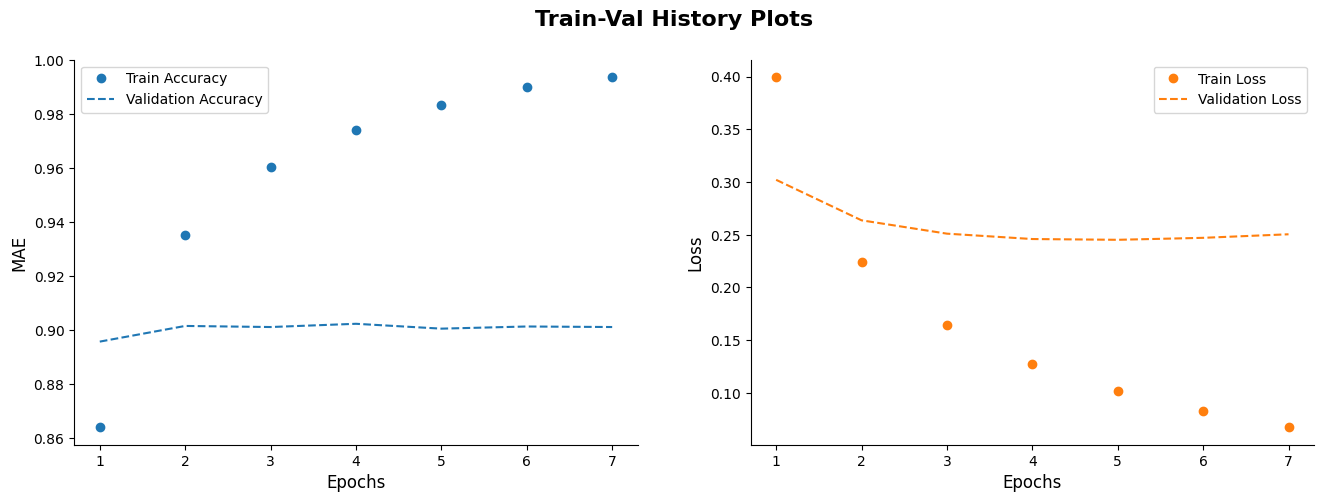

In [60]:
plot_history(history);

In [62]:
bigram_model = keras.models.load_model("models/bigram_model.keras")
bigram_acc = bigram_model.evaluate(bigram_test_ds)[1]
bigram_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9022 - loss: 0.2494


0.902239978313446

## 3 Sequence Models

### LSTM

#### Text Vectorization

In [10]:
max_length = 600
max_tokens = 30_000

text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="int",
    output_sequence_length=max_length,
)
text_vectorization.adapt(train_ds_no_labels)

In [11]:
sequence_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
sequence_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
sequence_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [12]:
x, y = next(sequence_test_ds.as_numpy_iterator())
x.shape

(8, 600)

#### One-Hot Encoder

In [13]:
from keras import ops

class OneHotEncoding(keras.Layer):
    def __init__(self, depth, **kwargs):
        super().__init__(**kwargs)
        self.depth = depth

    def call(self, inputs):
        flat_inputs = ops.reshape(ops.cast(inputs, "int"), [-1])
        one_hot_vectors = ops.eye(self.depth)
        outputs = ops.take(one_hot_vectors, flat_inputs, axis=0)
        return ops.reshape(outputs, ops.shape(inputs) + (self.depth,))

one_hot_encoding = OneHotEncoding(max_tokens)

In [14]:
x, y = next(sequence_train_ds.as_numpy_iterator())
one_hot_encoding(x).shape

torch.Size([8, 600, 30000])

#### Model Building

In [15]:
hidden_dim = 64

inputs = keras.Input(shape=(max_length,), dtype="int32")
x = one_hot_encoding(inputs)
x = layers.Bidirectional(layers.LSTM(hidden_dim))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="lstm_with_one_hot")

In [16]:
model.summary()

Model: "lstm_with_one_hot"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ one_hot_encoding                │ (None, 600, 30000)     │             0 │
│ (OneHotEncoding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │    15,393,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,393,409 (58.72 MB)

 Trainable params: 15,393,409 (58.72 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [18]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)
model_checkpoint = keras.callbacks.ModelCheckpoint(
    "models/lstm_model.keras", save_best_only=True
)

In [ ]:
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping, model_checkpoint],
)

In [ ]:
lstm_model = keras.models.load_model("models/lstm_model.keras")
lstm_acc = lstm_model.evaluate(sequence_test_ds)[1]
lstm_acc

### LSTM with Word Embedding

In [ ]:
hidden_dim = 64

inputs = keras.Input(shape=(max_length,), dtype="int32")
x = keras.layers.Embedding(
    input_dim=max_tokens,
    output_dim=hidden_dim,
    mask_zero=True,
)(inputs)
x = keras.layers.Bidirectional(keras.layers.LSTM(hidden_dim))(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="lstm_with_embedding")

In [ ]:
model.summary()

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)
model_checkpoint = keras.callbacks.ModelCheckpoint(
    "models/lstm_embedding.keras", save_best_only=True
)

In [ ]:
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping, model_checkpoint],
)

In [ ]:
lstm_with_embedding_model = keras.models.load_model("models/lstm_with_embedding.keras")
lstm_with_embedding_acc = lstm_model.evaluate(sequence_test_ds)[1]
lstm_with_embedding_acc

### Pretraining Word Embedding

In [ ]:
imdb_vocabulary = text_vectorization.get_vocabulary()
tokenize_no_padding = keras.layers.TextVectorization(
    vocabulary=imdb_vocabulary,
    split="whitespace",
    output_mode="int",
)

#### Creating CBOW Dataset

In [ ]:
import tensorflow as tf

context_size = 4
window_size = 9

def window_data(token_ids):
    num_windows = tf.maximum(tf.size(token_ids) - context_size * 2, 0)
    windows = tf.range(window_size)[None, :]
    windows = windows + tf.range(num_windows)[:, None]
    windowed_tokens = tf.gather(token_ids, windows)

    return tf.data.Dataset.from_tensor_slices(windowed_tokens)

def split_label(window):
    left = window[:context_size]
    right = window[context_size + 1 :]
    bag = tf.concat((left, right), axis=0)
    label = window[4]

    return bag, label

dataset = keras.utils.text_dataset_from_directory(
    imdb_extract_dir / "train", batch_size=None
)
dataset = dataset.map(lambda x, y: x, num_parallel_calls=8)
dataset = dataset.map(tokenize_no_padding, num_parallel_calls=8)
dataset = dataset.interleave(window_data, cycle_length=8, num_parallel_calls=8)
dataset = dataset.map(split_label, num_parallel_calls=8)

#### CBOW Model Training

In [ ]:
hidden_dim = 64

inputs = keras.Input(shape=(2 * context_size,))
cbow_embedding = layers.Embedding(
    max_tokens,
    hidden_dim,
)
x = cbow_embedding(inputs)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(max_tokens, activation="sigmoid")(x)
cbow_model = keras.Model(inputs, outputs)

In [ ]:
cbow_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)

In [ ]:
dataset = dataset.batch(1024).cache()
cbow_model.fit(dataset, epochs=4)

#### Loading Pretrained Embedding for Classification

In [ ]:
inputs = keras.Input(shape=(max_length,))
lstm_embedding = layers.Embedding(
    input_dim=max_tokens,
    output_dim=hidden_dim,
    mask_zero=True,
)
x = lstm_embedding(inputs)
x = layers.Bidirectional(layers.LSTM(hidden_dim))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="lstm_with_cbow")

In [ ]:
lstm_embedding.embeddings.assign(cbow_embedding.embeddings)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)
model_checkpoint = keras.callbacks.ModelCheckpoint(
    "models/lstm_pretrained_embedding.keras", save_best_only=True
)

In [ ]:
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping, model_checkpoint],
)

In [ ]:
lstm_with_pretrained_embedding = keras.models.load_model(
    "models/lstm_pretrained_embedding.keras")
lstm_pretrained_embedding_acc = lstm_with_pretrained_embedding.evaluate(sequence_test_ds)[1]
lstm_pretrained_embedding_acc